# Model Prototyping
## Workflow:
### 1. Chuẩn bị dữ liệu
### 2. Feature extraction với embeddings
### 3. Huấn luyện nhiều models (baseline + candidates)
### 4. Đánh giá và so sánh performance
### 5. Hyperparameter tuning cho model tốt nhất
### 6. Phân tích chi tiết kết quả

In [58]:
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings("ignore")
CACHE_DIR="./cache"

### 1. Chuẩn bị dữ liệu

In [37]:
from datasets import load_dataset
from collections import Counter
from sklearn.model_selection import train_test_split
# 1. LOAD DỮ LIỆU
# ==============================================================================
ds = load_dataset("json", data_files="../data/processed/data_arxiv_preprocessed.jsonl")
print("Dataset loaded successfully!")
print(ds)

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2292057
    })
})


In [38]:
# 2. KHÁM PHÁ DỮ LIỆU (Data Exploration)
# ==============================================================================

# Hiển thị 4 mẫu đầu tiên để kiểm tra cấu trúc dữ liệu
print("\n" + "="*80)
print("SAMPLE DATA")
print("="*80)
for i in range(4):
    print(f"\nMẫu {i+1}:")
    print(f"Text: {ds['train'][i]['text'][:200]}...")  # Chỉ hiển thị 200 ký tự đầu
    print(f"Label: {ds['train'][i]['label']}")

# Phân tích phân bố categories trong toàn bộ dataset
# Đếm số lượng mỗi category trong toàn bộ dataset
all_labels = ds['train']['label']
category_counter = Counter(all_labels)

# Tính tổng số mẫu đã xử lý
processed_count = len(all_labels)
print("-" * 80)
for cat, count in category_counter.most_common(38):
    # Tính phần trăm
    percentage = (count / processed_count) * 100
    
    # Tạo thanh bar bằng ký tự █ (độ dài tỷ lệ với phần trăm)
    bar = "█" * int(percentage)
    
    # In ra với format đẹp: tên category | số lượng (phần trăm) bar
    print(f"{cat:10s} | {count:7,} ({percentage:5.2f}%) {bar}")

print("-" * 80)
print(f"Tổng số categories:        {len(category_counter)}")
print(f"Tổng số mẫu:               {processed_count:,}")


SAMPLE DATA

Mẫu 1:
Text: a fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders all nexttoleading order perturbative contributions f...
Label: hep-ph

Mẫu 2:
Text: we describe a new algorithm the kellpebble game with colors and use it obtain a characterization of the family of kellsparse graphs and algorithmic solutions to a family of problems concerning tree de...
Label: math

Mẫu 3:
Text: the evolution of earthmoon system is described by the dark matter field fluid model proposed in the meeting of division of particle and field american physical society the current behavior of the eart...
Label: physics

Mẫu 4:
Text: we show that a determinant of stirling cycle numbers counts unlabeled acyclic singlesource automata the proof involves a bijection from these automata to certain marked lattice paths and a signreversi...
Label: math
--------------------------------------------------------------

In [39]:
# 4. LẤY MẪU CÂN BẰNG (Balanced Sampling)
# ==============================================================================

print("\n" + "="*80)
print("LẤY MẪU CÂN BẰNG")
print("="*80)

# Chọn 5 categories chính để phân loại
CATEGORIES_TO_SELECT = ['astro-ph', 'cond-mat', 'cs', 'math', 'physics']
TARGET_PER_CATEGORY = 200  # Số lượng mẫu mong muốn cho mỗi category

# Khởi tạo danh sách lưu mẫu và bộ đếm
samples = []
category_counts = {cat: 0 for cat in CATEGORIES_TO_SELECT}

# Duyệt qua dataset và lấy mẫu cân bằng
for sample in ds['train']:
    current_category = sample['label']
    
    # Bỏ qua các category không nằm trong danh sách chọn
    if current_category not in CATEGORIES_TO_SELECT:
        continue
    
    # Thêm mẫu nếu category chưa đủ số lượng
    if category_counts[current_category] < TARGET_PER_CATEGORY:
        samples.append(sample)
        category_counts[current_category] += 1
    
    # Dừng lại khi tất cả categories đã đủ số lượng
    if all(count >= TARGET_PER_CATEGORY for count in category_counts.values()):
        break

print(f"\nTổng số mẫu đã lấy: {len(samples)}")
print("\nPhân bố mẫu theo category:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")


LẤY MẪU CÂN BẰNG

Tổng số mẫu đã lấy: 1000

Phân bố mẫu theo category:
  astro-ph: 200
  cond-mat: 200
  cs: 200
  math: 200
  physics: 200


In [40]:
# 5. TẠO LABEL MAPPING
# ==============================================================================

print("\n" + "="*80)
print("LABEL ENCODING")
print("="*80)

# Lấy danh sách labels duy nhất và sắp xếp
unique_labels = set(sample['label'] for sample in samples)
sorted_labels = sorted(unique_labels)

# Tạo mapping giữa label (string) và ID (integer) cho model
label_to_id = {label: idx for idx, label in enumerate(sorted_labels)}
id_to_label = {idx: label for idx, label in enumerate(sorted_labels)}

print("\nMapping từ Label sang ID:")
for label, label_id in label_to_id.items():
    print(f"  {label} --> {label_id}")


LABEL ENCODING

Mapping từ Label sang ID:
  astro-ph --> 0
  cond-mat --> 1
  cs --> 2
  math --> 3
  physics --> 4


In [41]:
print("\n" + "="*80)
print("CHIA DỮ LIỆU TRAIN/TEST")
print("="*80)

# Chuẩn bị dữ liệu đầu vào (X) và nhãn (y)
X_full = [sample['text'] for sample in samples]
y_full = [label_to_id[sample['label']] for sample in samples]

# Chia 80% train, 20% test với stratify để giữ tỷ lệ các classes
X_train, X_test, y_train, y_test = train_test_split(
    X_full, 
    y_full, 
    test_size=0.2,      # 20% cho test set
    random_state=42,    # Seed để tái tạo kết quả
    stratify=y_full     # Giữ tỷ lệ các classes trong train và test
)

print(f"\nSố lượng mẫu training: {len(X_train)}")
print(f"Số lượng mẫu test: {len(X_test)}")


CHIA DỮ LIỆU TRAIN/TEST

Số lượng mẫu training: 800
Số lượng mẫu test: 200


In [42]:
# 7. KIỂM TRA PHÂN BỐ
# ==============================================================================

print("\n" + "="*80)
print("KIỂM TRA PHÂN BỐ LABELS")
print("="*80)

# Kiểm tra phân bố trong train set
print("\nPhân bố trong Train set:")
train_dist = Counter(y_train)
for label_id in sorted(train_dist.keys()):
    percentage = (train_dist[label_id] / len(y_train)) * 100
    print(f"  {id_to_label[label_id]}: {train_dist[label_id]} ({percentage:.1f}%)")

# Kiểm tra phân bố trong test set
print("\nPhân bố trong Test set:")
test_dist = Counter(y_test)
for label_id in sorted(test_dist.keys()):
    percentage = (test_dist[label_id] / len(y_test)) * 100
    print(f"  {id_to_label[label_id]}: {test_dist[label_id]} ({percentage:.1f}%)")

print("\n" + "="*80)
print("HOÀN THÀNH CHUẨN BỊ DỮ LIỆU!")
print("="*80)


KIỂM TRA PHÂN BỐ LABELS

Phân bố trong Train set:
  astro-ph: 160 (20.0%)
  cond-mat: 160 (20.0%)
  cs: 160 (20.0%)
  math: 160 (20.0%)
  physics: 160 (20.0%)

Phân bố trong Test set:
  astro-ph: 40 (20.0%)
  cond-mat: 40 (20.0%)
  cs: 40 (20.0%)
  math: 40 (20.0%)
  physics: 40 (20.0%)

HOÀN THÀNH CHUẨN BỊ DỮ LIỆU!


### 2.

In [43]:
#Tạo class EmbeddingVectorizer
class EmbeddingVectorizer:
    def __init__(self,
                 model_name: str = 'intfloat/multilingual-e5-base',
                 normalize: bool = True):
        self.model = SentenceTransformer(model_name)
        self.normalize = normalize
    
    def _format_inputs(self,
                       texts: List[str],
                       mode: Literal['query', 'passage']) -> List[str]:
        if mode not in {'query', "passage"}:
            raise ValueError('Mode must be either `query` or `passage`')
        return [f"{mode}: {text.strip()}" for text in texts]
    
    def transform(self,
                  texts: List[str],
                  mode: Literal['query', 'passage'] = 'query') -> List[List[float]]:
        if mode == 'raw':
            inputs = texts
        else:
            inputs = self._format_inputs(texts, mode)
        
        embeddings = self.model.encode(inputs, normalize_embeddings=self.normalize)
        return embeddings.tolist()
    
    def transform_numpy(self,
                        texts: List[str],
                        mode: Literal['query', 'passage'] = 'query') -> np.ndarray:
        return np.array(self.transform(texts, mode=mode))

In [44]:
print("\n" + "="*80)
print("📊 PHẦN 1: MÃ HÓA DỮ LIỆU VỚI BAG-OF-WORDS")
print("="*80)
# --- Count Vectorization (Binary BoW) ---
print("\n🔄 Đang mã hóa với Count Vectorizer (Binary)...")
count_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    binary=True,              # Binary mode: chỉ quan tâm từ có/không
    strip_accents='unicode'
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print(f"✅ Count Vectorizer encoding completed!")
print(f"   Shape X_train: {X_train_count.shape}")
print(f"   Shape X_test:  {X_test_count.shape}")



📊 PHẦN 1: MÃ HÓA DỮ LIỆU VỚI BAG-OF-WORDS

🔄 Đang mã hóa với Count Vectorizer (Binary)...
✅ Count Vectorizer encoding completed!
   Shape X_train: (800, 5000)
   Shape X_test:  (200, 5000)


In [45]:
# 3. MÃ HÓA DỮ LIỆU - SENTENCE EMBEDDINGS

# Khởi tạo EmbeddingVectorizer
embedding_vectorizer = EmbeddingVectorizer(
    model_name='intfloat/multilingual-e5-base',
    normalize=True
)

# Transform training và test data
print("\n🔄 Đang mã hóa training data...")
X_train_embeddings = embedding_vectorizer.transform_numpy(X_train, mode='passage')

print("🔄 Đang mã hóa test data...")
X_test_embeddings = embedding_vectorizer.transform_numpy(X_test, mode='passage')

print(f"\n✅ Sentence Embeddings encoding completed!")
print(f"   Shape X_train: {X_train_embeddings.shape}")
print(f"   Shape X_test:  {X_test_embeddings.shape}")
print(f"   Embedding dimension: {X_train_embeddings.shape[1]}")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 73dfb79f-9359-4bbe-9eb7-fe63926bd76c)')' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].



🔄 Đang mã hóa training data...
🔄 Đang mã hóa test data...

✅ Sentence Embeddings encoding completed!
   Shape X_train: (800, 768)
   Shape X_test:  (200, 768)
   Embedding dimension: 768


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, 
                   model_name="Model", vectorization_method=""):
    """
    Hàm huấn luyện và đánh giá model với các metrics chi tiết
    ...
    """
    full_name = f"{model_name} ({vectorization_method})"
    
    # Train model
    print(f"🔄 Đang huấn luyện {full_name}...")
    model.fit(X_train, y_train)

    # Predict trên CẢ train và test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics cho TRAIN
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    
    # Calculate metrics cho TEST
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    
    # Tính gap để detect overfitting
    acc_gap = train_accuracy - test_accuracy
    f1_gap = train_f1 - test_f1
    
    # Classification report (giữ nguyên)
    report = classification_report(
        y_test, y_test_pred,  # ← Đổi y_pred thành y_test_pred
        target_names=sorted_labels,
        output_dict=True,
        zero_division=0
    )

    print(f"✅ {full_name} - Completed!")
    print(f"   Train → Acc: {train_accuracy:.4f} | f1-score: {train_f1:.4f}")
    print(f"   Test  → Acc: {test_accuracy:.4f} | F1: {test_f1:.4f}")
    print(f"   Gap   → Acc: {acc_gap:+.4f} | F1: {f1_gap:+.4f}", end="")
    
    # Cảnh báo overfitting
    if f1_gap > 0.05:
        print(" ⚠️ Potential overfitting!")
    else:
        print(" ✅")
    print()
    
    return {
        'model_name': model_name,
        'vectorization': vectorization_method,
        'full_name': full_name,
        'model': model,
        'y_pred': y_test_pred,  # ← Đổi y_pred thành y_test_pred
        
        'train_accuracy': train_accuracy,
        'train_precision': train_precision,
        'train_recall': train_recall,
        'train_f1': train_f1,
        'test_accuracy': test_accuracy,  # Đổi tên từ 'accuracy'
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'acc_gap': acc_gap,
        'f1_gap': f1_gap,

        
        'report': report
    }

In [47]:

results_count = []

# SVM RBF
svm_rbf_count = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
results_count.append(evaluate_model(
    svm_rbf_count, 
    X_train_count, y_train, 
    X_test_count, y_test,
    model_name="SVM RBF",
    vectorization_method="Count"
))

# SVM Linear
svm_linear_count = SVC(kernel='linear', C=1.0, random_state=42)
results_count.append(evaluate_model(
    svm_linear_count, 
    X_train_count, y_train, 
    X_test_count, y_test,
    model_name="SVM Linear",
    vectorization_method="Count"
))

# Logistic Regression
logreg_count = LogisticRegression(
    max_iter=2000, C=1.0, solver='lbfgs', 
    multi_class='auto', random_state=42
)
results_count.append(evaluate_model(
    logreg_count,
    X_train_count, y_train,
    X_test_count, y_test,
    model_name="Logistic Regression",
    vectorization_method="Count"
))

# KNN
knn_count = KNeighborsClassifier(n_neighbors=5, metric='cosine')
results_count.append(evaluate_model(
    knn_count,
    X_train_count, y_train,
    X_test_count, y_test,
    model_name="KNN",
    vectorization_method="Count"
))



🔄 Đang huấn luyện SVM RBF (Count)...
✅ SVM RBF (Count) - Completed!
   Train → Acc: 0.9762 | F1: 0.9766
   Test  → Acc: 0.7150 | F1: 0.7102
   Gap   → Acc: +0.2612 | F1: +0.2664 ⚠️ Potential overfitting!

🔄 Đang huấn luyện SVM Linear (Count)...
✅ SVM Linear (Count) - Completed!
   Train → Acc: 1.0000 | F1: 1.0000
   Test  → Acc: 0.7050 | F1: 0.7080
   Gap   → Acc: +0.2950 | F1: +0.2920 ⚠️ Potential overfitting!

🔄 Đang huấn luyện Logistic Regression (Count)...
✅ Logistic Regression (Count) - Completed!
   Train → Acc: 1.0000 | F1: 1.0000
   Test  → Acc: 0.7550 | F1: 0.7577
   Gap   → Acc: +0.2450 | F1: +0.2423 ⚠️ Potential overfitting!

🔄 Đang huấn luyện KNN (Count)...
✅ KNN (Count) - Completed!
   Train → Acc: 0.8175 | F1: 0.8068
   Test  → Acc: 0.6950 | F1: 0.6769
   Gap   → Acc: +0.1225 | F1: +0.1299 ⚠️ Potential overfitting!



In [48]:

results_embeddings = []


# SVM RBF với Embeddings
svm_rbf_emb = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
results_embeddings.append(evaluate_model(
    svm_rbf_emb,
    X_train_embeddings, y_train,
    X_test_embeddings, y_test,
    model_name="SVM RBF",
    vectorization_method="Embeddings"
))
# SVM Linear với Embeddings
svm_linear_emb = SVC(kernel='linear', C=1.0, random_state=42)
results_embeddings.append(evaluate_model(
    svm_linear_emb, 
    X_train_embeddings, y_train, 
    X_test_embeddings, y_test,
    model_name="SVM Linear",
    vectorization_method="Embeddings"
))


# KNN với Embeddings (cosine similarity)
knn_emb = KNeighborsClassifier(n_neighbors=5, metric='cosine')
results_embeddings.append(evaluate_model(
    knn_emb,
    X_train_embeddings, y_train,
    X_test_embeddings, y_test,
    model_name="KNN",
    vectorization_method="Embeddings"
))

# Logistic Regression với Embeddings
logreg_emb = LogisticRegression(
    max_iter=2000, C=1.0, solver='lbfgs', 
    multi_class='auto', random_state=42
)
results_embeddings.append(evaluate_model(
    logreg_emb,
    X_train_embeddings, y_train,
    X_test_embeddings, y_test,
    model_name="Logistic Regression",
    vectorization_method="Embeddings"
))


🔄 Đang huấn luyện SVM RBF (Embeddings)...
✅ SVM RBF (Embeddings) - Completed!
   Train → Acc: 0.9225 | F1: 0.9223
   Test  → Acc: 0.8400 | F1: 0.8383
   Gap   → Acc: +0.0825 | F1: +0.0840 ⚠️ Potential overfitting!

🔄 Đang huấn luyện SVM Linear (Embeddings)...
✅ SVM Linear (Embeddings) - Completed!
   Train → Acc: 0.8912 | F1: 0.8899
   Test  → Acc: 0.8250 | F1: 0.8235
   Gap   → Acc: +0.0663 | F1: +0.0665 ⚠️ Potential overfitting!

🔄 Đang huấn luyện KNN (Embeddings)...
✅ KNN (Embeddings) - Completed!
   Train → Acc: 0.8475 | F1: 0.8387
   Test  → Acc: 0.7750 | F1: 0.7631
   Gap   → Acc: +0.0725 | F1: +0.0757 ⚠️ Potential overfitting!

🔄 Đang huấn luyện Logistic Regression (Embeddings)...
✅ Logistic Regression (Embeddings) - Completed!
   Train → Acc: 0.8888 | F1: 0.8856
   Test  → Acc: 0.7900 | F1: 0.7831
   Gap   → Acc: +0.0988 | F1: +0.1024 ⚠️ Potential overfitting!




📊 BẢNG SO SÁNH KẾT QUẢ TẤT CẢ MODELS
              Model Vectorization                        Full Name  Accuracy  Precision  Recall  F1-Score
            SVM RBF    Embeddings             SVM RBF (Embeddings)     0.840   0.849199   0.840  0.838286
         SVM Linear    Embeddings          SVM Linear (Embeddings)     0.825   0.829658   0.825  0.823473
Logistic Regression    Embeddings Logistic Regression (Embeddings)     0.790   0.779625   0.790  0.783127
                KNN    Embeddings                 KNN (Embeddings)     0.775   0.781103   0.775  0.763080
Logistic Regression         Count      Logistic Regression (Count)     0.755   0.767855   0.755  0.757698
            SVM RBF         Count                  SVM RBF (Count)     0.715   0.728269   0.715  0.710236
         SVM Linear         Count               SVM Linear (Count)     0.705   0.717827   0.705  0.707967
                KNN         Count                      KNN (Count)     0.695   0.692614   0.695  0.676875

🏆 BEST 

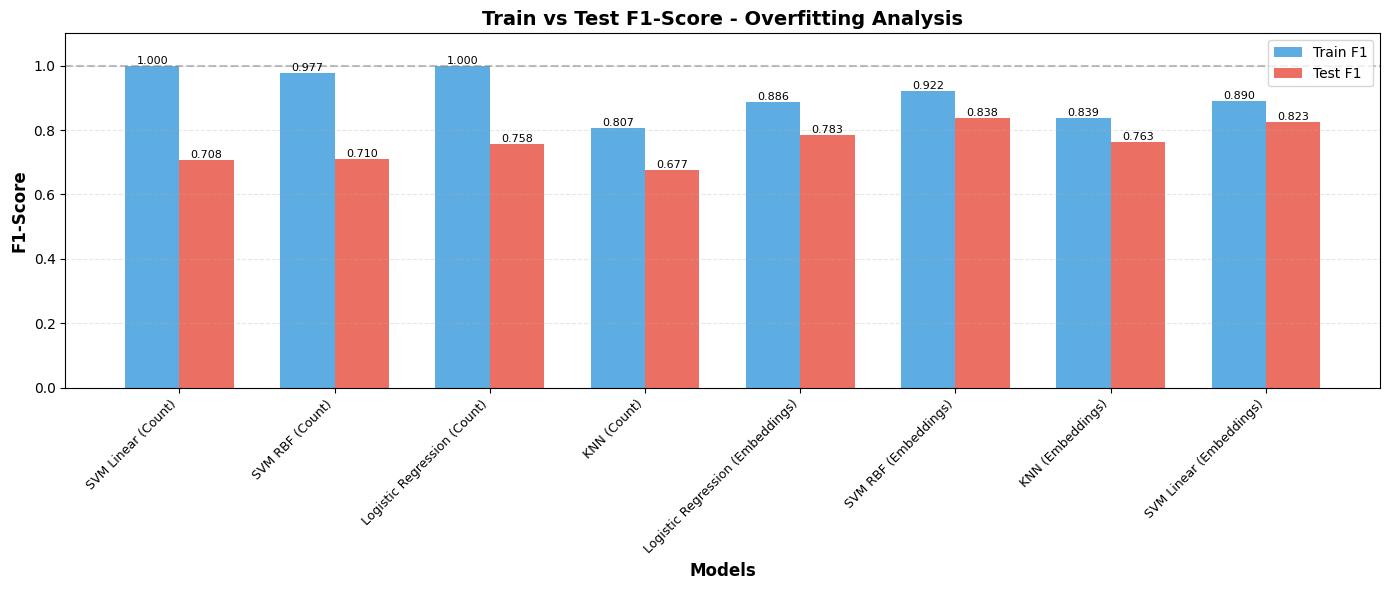

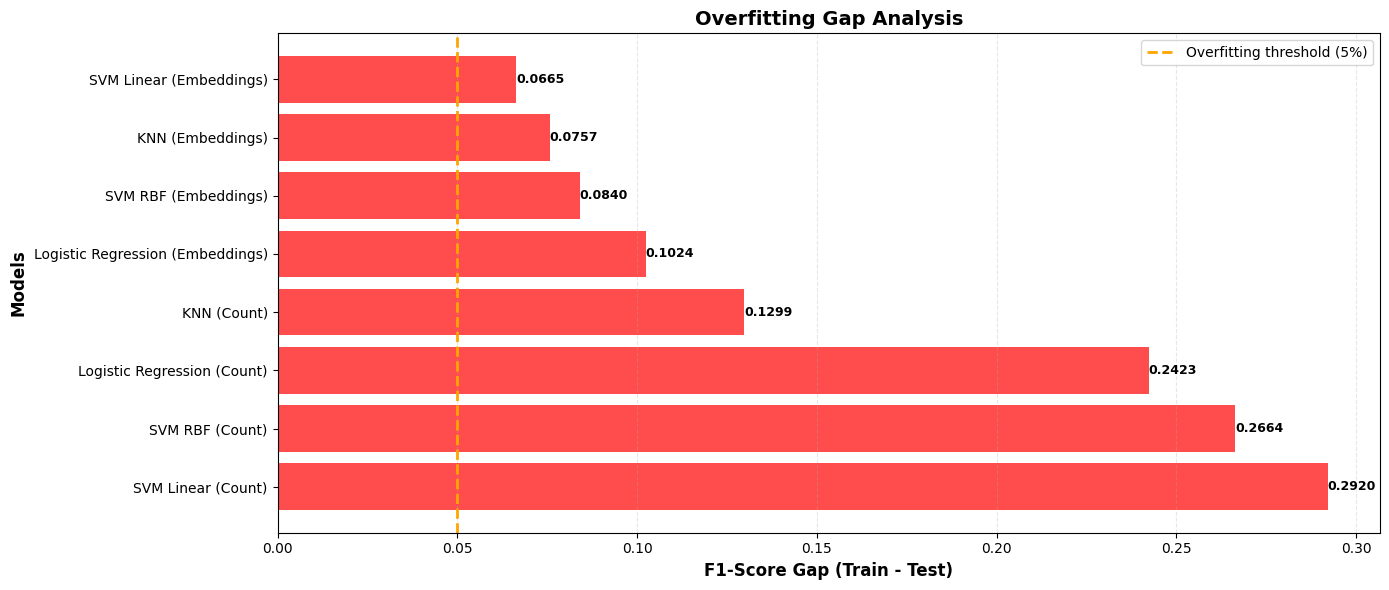

In [49]:
# Tổng hợp tất cả kết quả
all_results =results_count + results_embeddings

# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Vectorization': r['vectorization'],
        'Full Name': r['full_name'],
        'Accuracy': r['test_accuracy'],      
        'Precision': r['test_precision'],    
        'Recall': r['test_recall'],          
        'F1-Score': r['test_f1']             
    }
    for r in all_results
])

# Sắp xếp theo F1-Score
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("📊 BẢNG SO SÁNH KẾT QUẢ TẤT CẢ MODELS")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)

# Highlight best model
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.iloc[best_model_idx]
print(f"\n🏆 BEST MODEL OVERALL:")
print(f"   {best_model['Full Name']}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")

# So sánh theo phương pháp vectorization
print("\n" + "="*90)
print("📈 SO SÁNH THEO PHƯƠNG PHÁP MÃ HÓA")
print("="*90)

for method in ['Count', 'Embeddings']:
    method_results = comparison_df[comparison_df['Vectorization'] == method]
    best_in_method = method_results.iloc[0]
    avg_f1 = method_results['F1-Score'].mean()
    
    print(f"\n{method}:")
    print(f"   Best model: {best_in_method['Model']} (F1: {best_in_method['F1-Score']:.4f})")
    print(f"   Average F1: {avg_f1:.4f}")
# VISUALIZATION: TRAIN VS TEST - OVERFITTING CHECK
# ==============================================================================

print("\n" + "="*90)
print("🔍 PHÂN TÍCH OVERFITTING (TRAIN VS TEST)")
print("="*90)

# Tạo DataFrame cho train/test comparison
overfitting_data = []
for r in all_results:
    overfitting_data.append({
        'Model': r['full_name'],
        'Train F1': r['train_f1'],
        'Test F1': r['test_f1'],
        'F1 Gap': r['f1_gap'],
        'Train Acc': r['train_accuracy'],
        'Test Acc': r['test_accuracy'],
        'Acc Gap': r['acc_gap']
    })

overfitting_df = pd.DataFrame(overfitting_data)
overfitting_df = overfitting_df.sort_values('F1 Gap', ascending=False)

print("\n📊 Train vs Test Performance:")
print(overfitting_df.to_string(index=False))

# Highlight models với overfitting
overfitted_models = overfitting_df[overfitting_df['F1 Gap'] > 0.05]
if len(overfitted_models) > 0:
    print(f"\n⚠️ Models với dấu hiệu overfitting (F1 gap > 5%):")
    for _, row in overfitted_models.iterrows():
        print(f"   {row['Model']}: Gap = {row['F1 Gap']:.4f}")
else:
    print("\n✅ Không có model nào có dấu hiệu overfitting nghiêm trọng")

# Plot 1: Bar chart - Train vs Test F1
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(overfitting_df))
width = 0.35

bars1 = ax.bar(x - width/2, overfitting_df['Train F1'], width, 
               label='Train F1', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, overfitting_df['Test F1'], width, 
               label='Test F1', color='#e74c3c', alpha=0.8)

# Thêm values trên bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test F1-Score - Overfitting Analysis', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(overfitting_df['Model'], rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Plot 2: Gap visualization
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red' if gap > 0.05 else 'green' for gap in overfitting_df['F1 Gap']]
bars = ax.barh(overfitting_df['Model'], overfitting_df['F1 Gap'], color=colors, alpha=0.7)

# Thêm threshold line
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Overfitting threshold (5%)')

# Thêm values
for i, (bar, gap) in enumerate(zip(bars, overfitting_df['F1 Gap'])):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., 
            f'{gap:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('F1-Score Gap (Train - Test)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Gap Analysis', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*90)


🎨 Đang tạo visualizations...


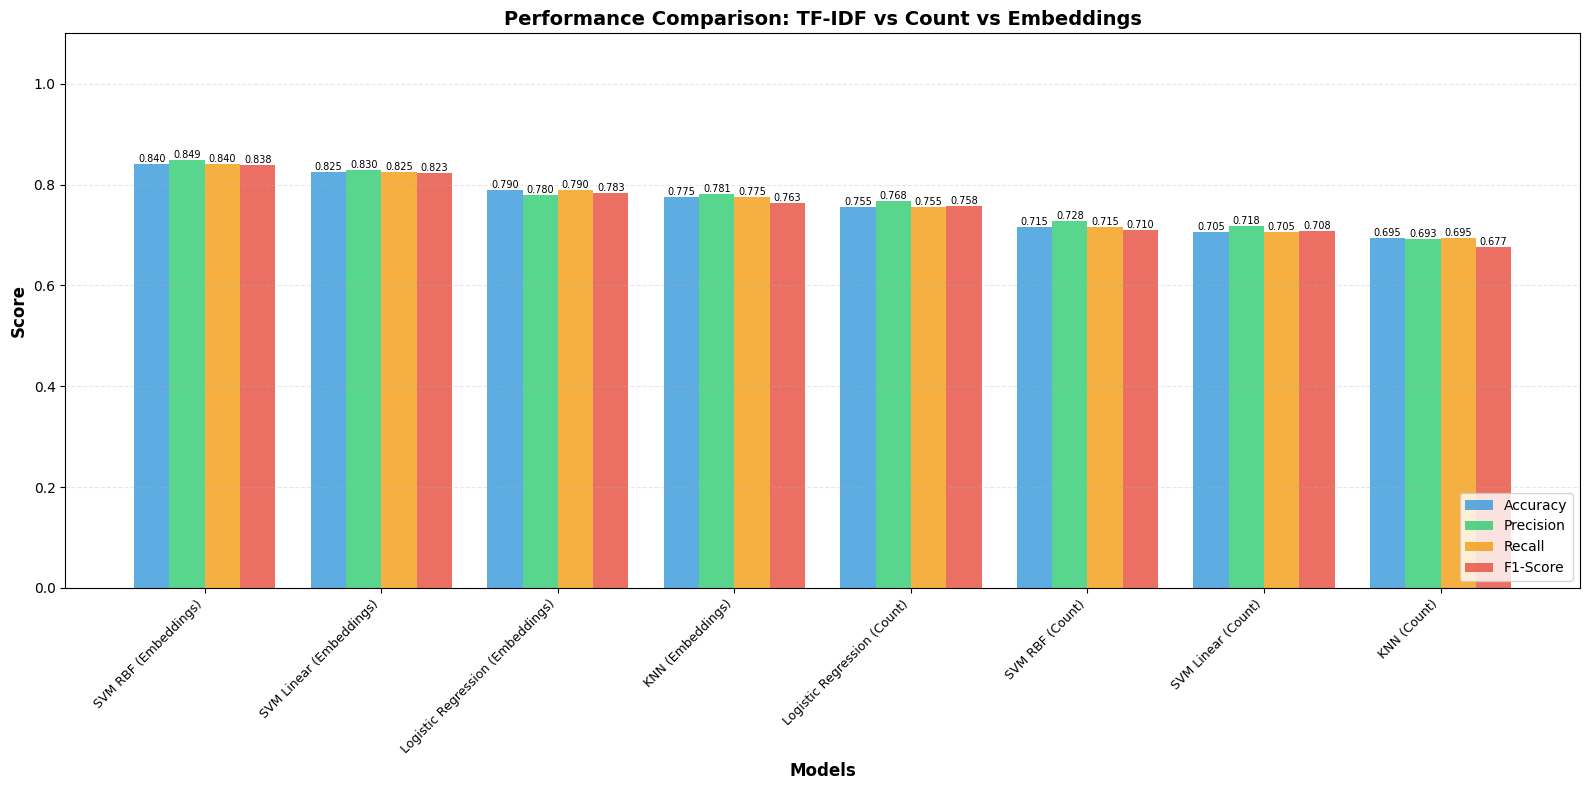

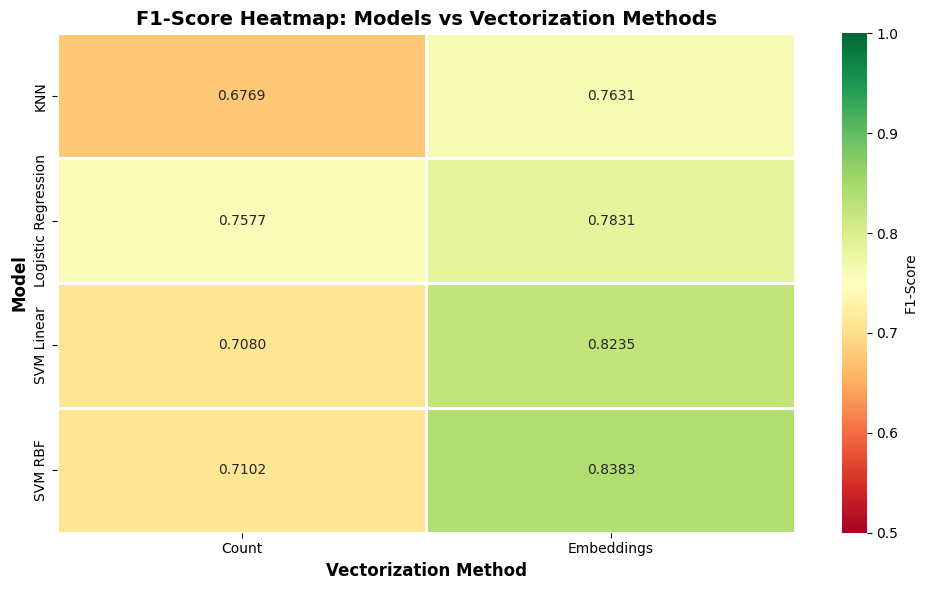

In [50]:
# 9. VISUALIZATIONS - COMPARISON CHART
# ==============================================================================

print("\n🎨 Đang tạo visualizations...")

# Figure 1: Grouped Bar Chart - So sánh các metrics
fig, ax = plt.subplots(figsize=(16, 8))

# Nhóm theo vectorization method
methods = comparison_df['Vectorization'].unique()
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = width * (i - 1.5)
    bars = ax.bar(x + offset, comparison_df[metric], width, 
                   label=metric, color=color, alpha=0.8)
    
    # Thêm giá trị trên mỗi cột
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=0)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: TF-IDF vs Count vs Embeddings', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Full Name'], rotation=45, ha='right', fontsize=9)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


# Figure 2: Heatmap - F1-Score comparison
pivot_f1 = comparison_df.pivot(index='Model', columns='Vectorization', values='F1-Score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn', 
            vmin=0.5, vmax=1.0, linewidths=1, 
            cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score Heatmap: Models vs Vectorization Methods', 
          fontsize=14, fontweight='bold')
plt.xlabel('Vectorization Method', fontsize=12, fontweight='bold')
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



📊 Confusion Matrices for 8 Models:


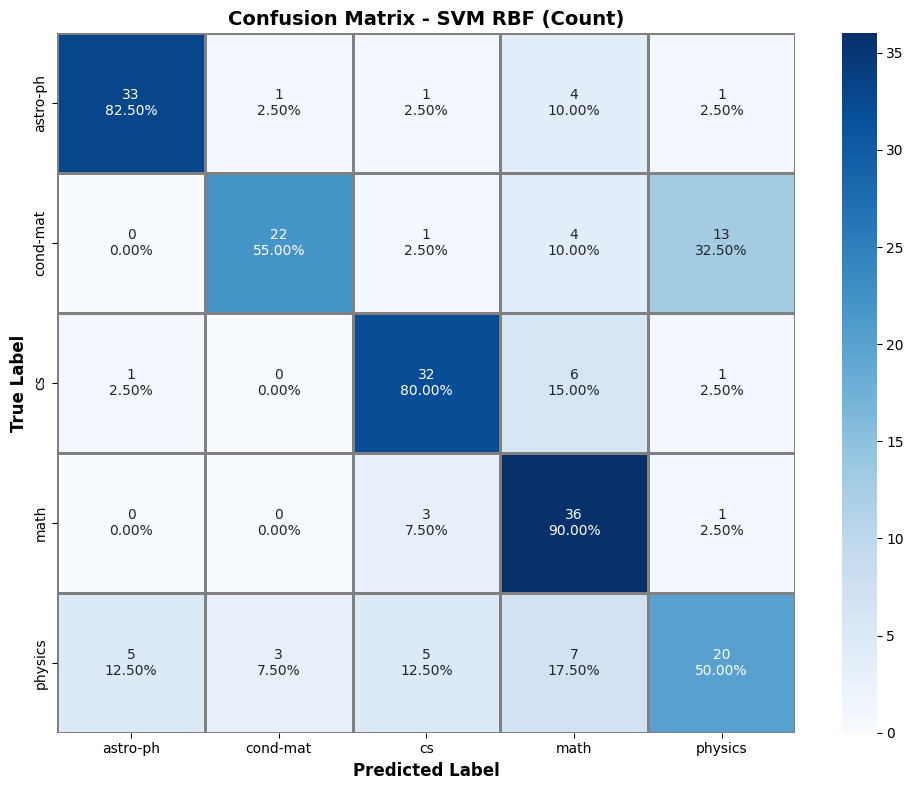

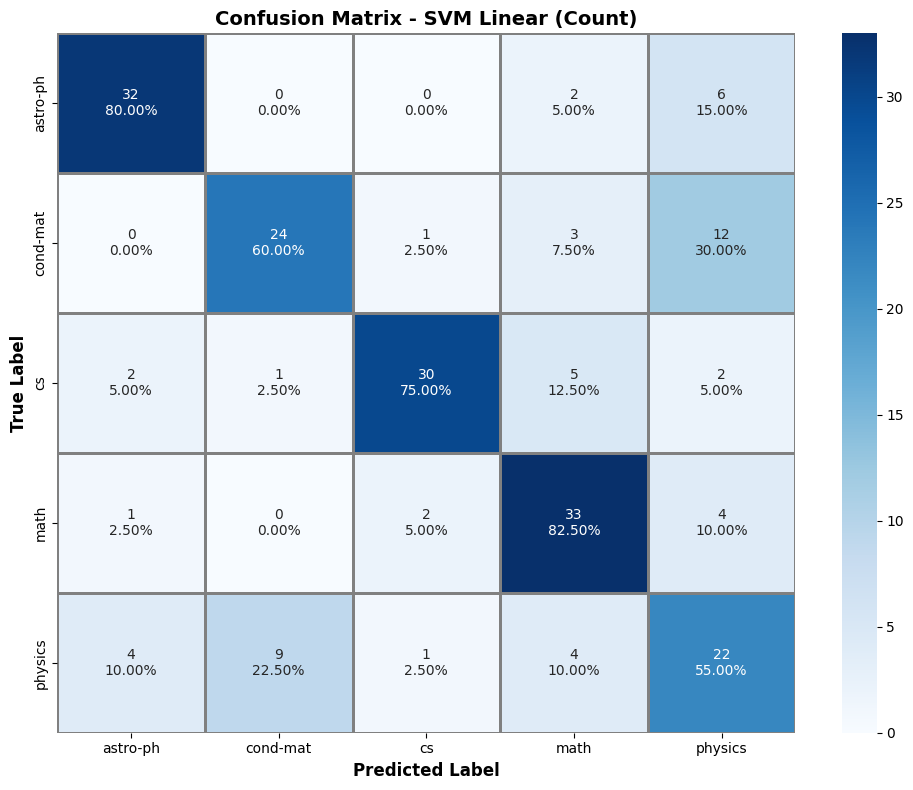

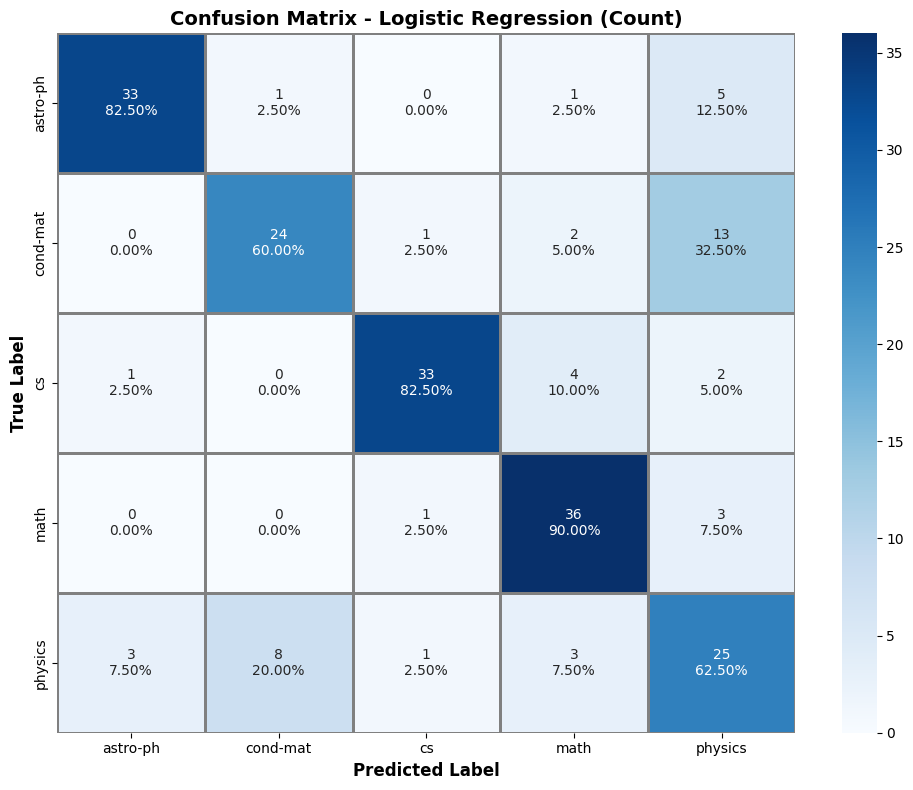

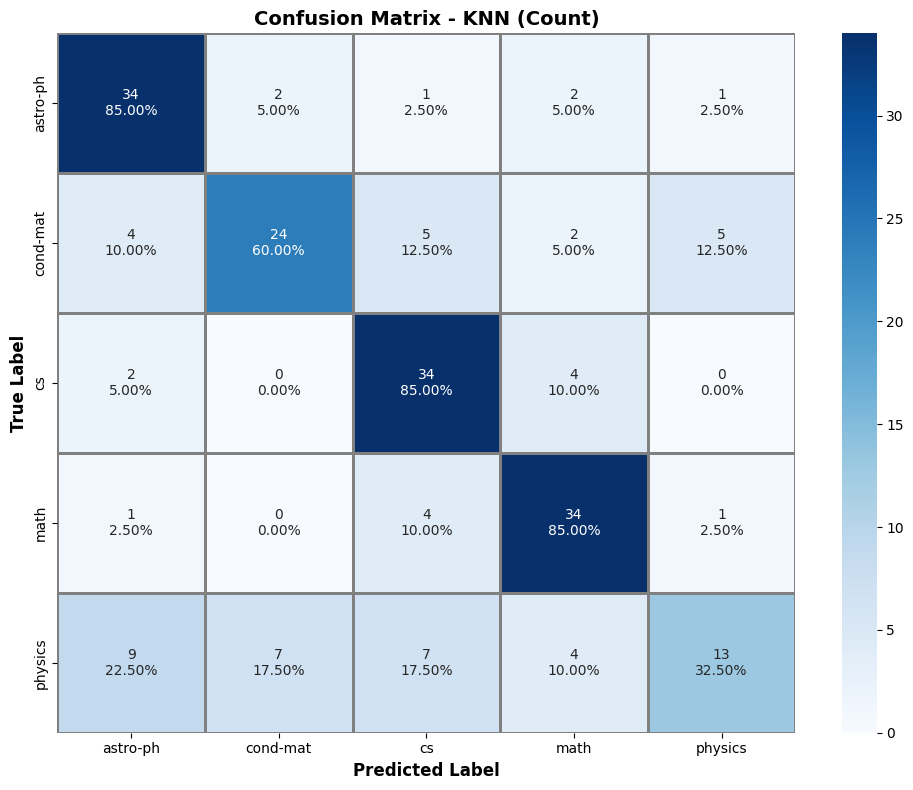

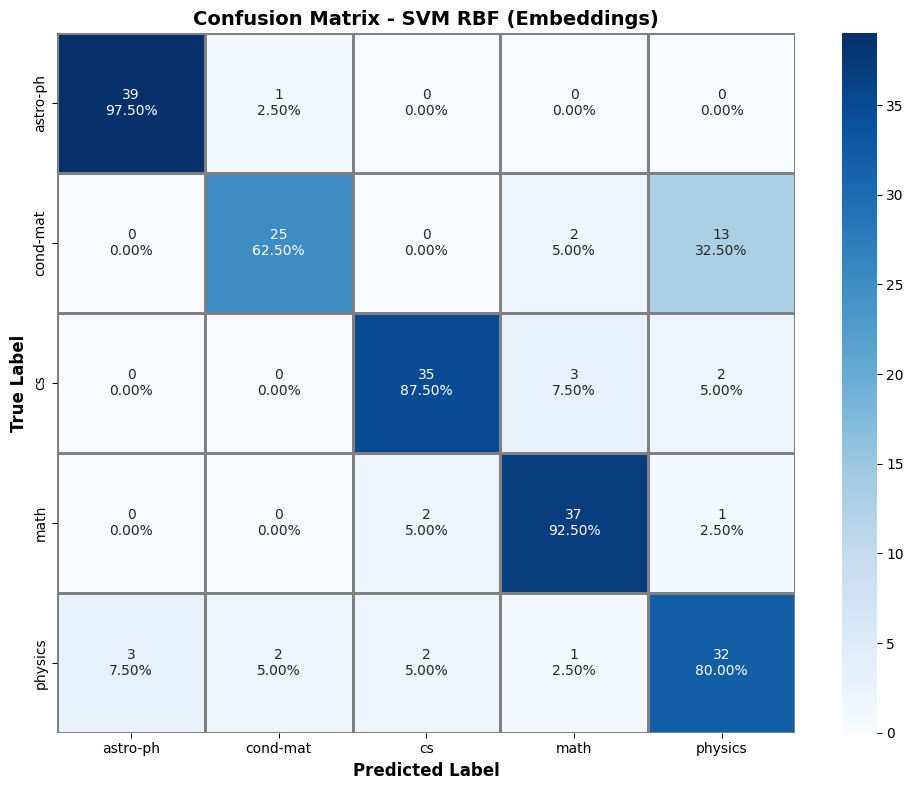

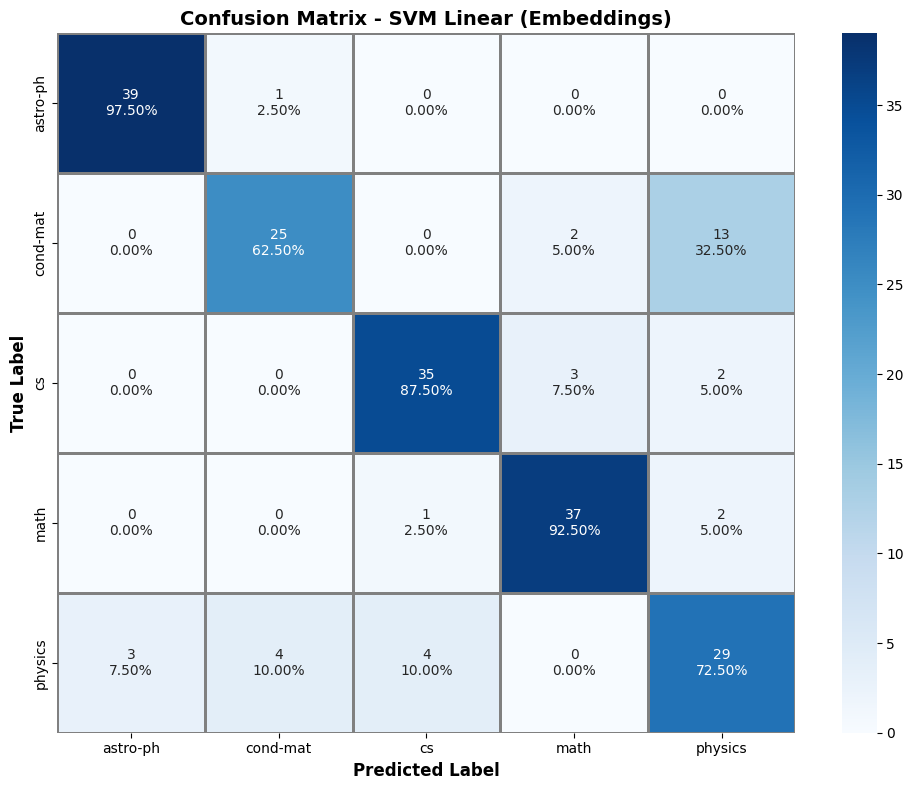

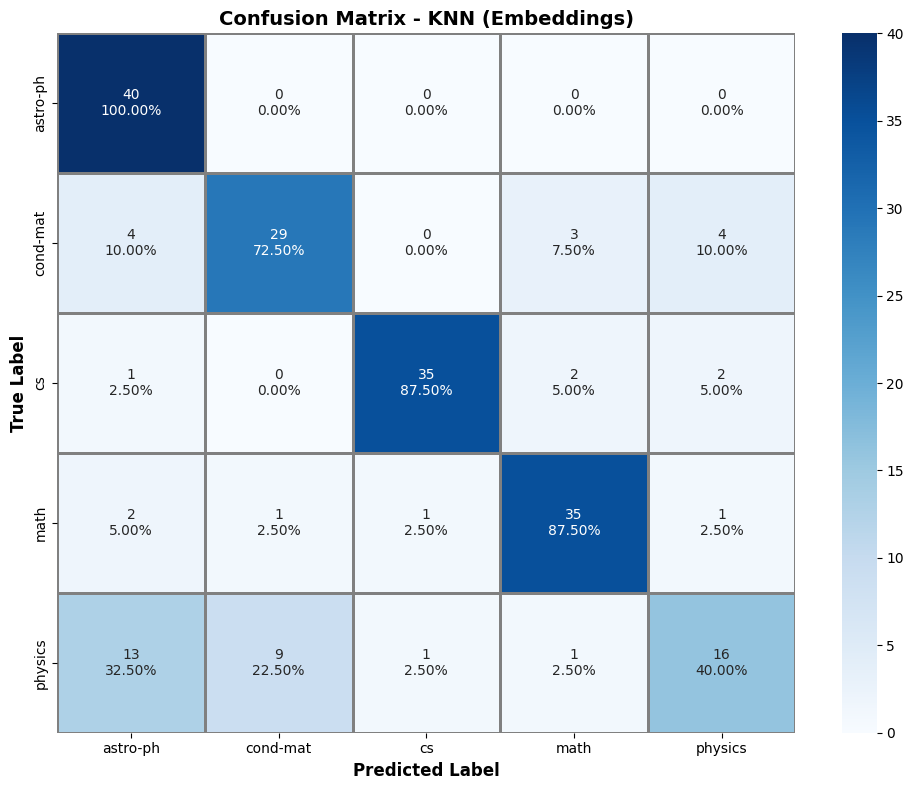

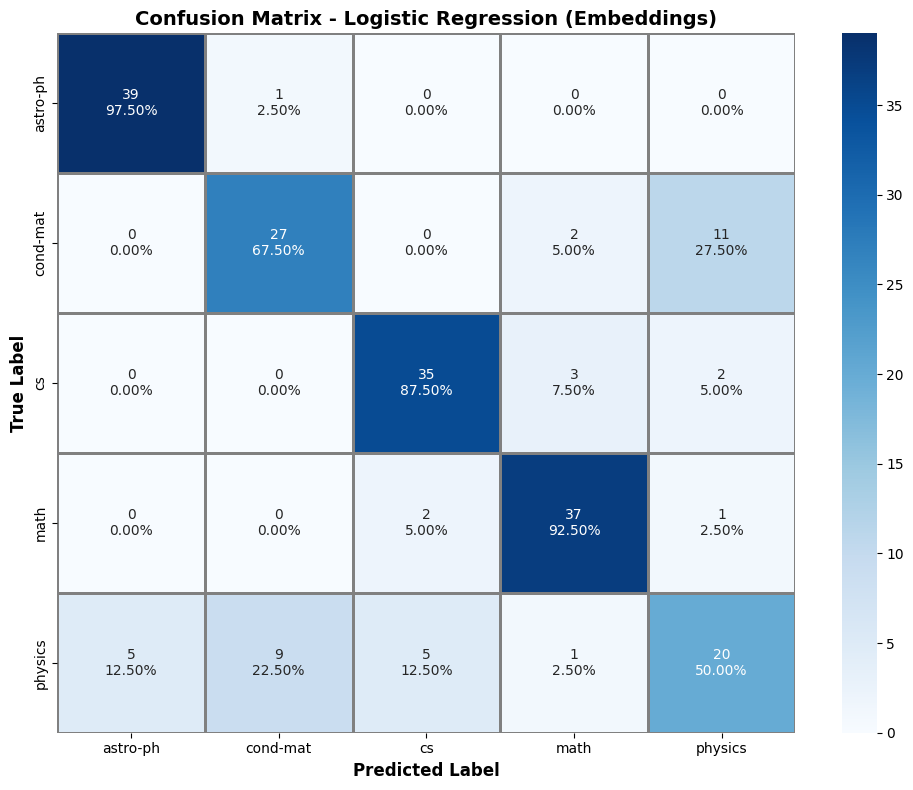

In [ ]:
# 10. CONFUSION MATRICES
# ==============================================================================

def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    """
    Vẽ confusion matrix với raw counts và normalized percentages
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Tạo annotations với cả count và percentage
    annotations = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            raw = cm[i, j]
            norm = cm_normalized[i, j]
            annotations[i, j] = f"{raw}\n{norm:.2%}"
    
    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=annotations, fmt="", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=1, linecolor='gray')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Vẽ confusion matrix cho 8 models
print("\n📊 Confusion Matrices for 8 Models:")
top_8_results = [
    r for _, r in zip(range(8), sorted(all_results, key=lambda x: x.get('F1', 0), reverse=True))
]

for result in top_8_results:
    plot_confusion_matrix(
        y_test, 
        result['y_pred'], 
        sorted_labels,
        title=f"Confusion Matrix - {result['full_name']}")


📈 PHẦN 7: PHÂN TÍCH PERFORMANCE THEO CLASS


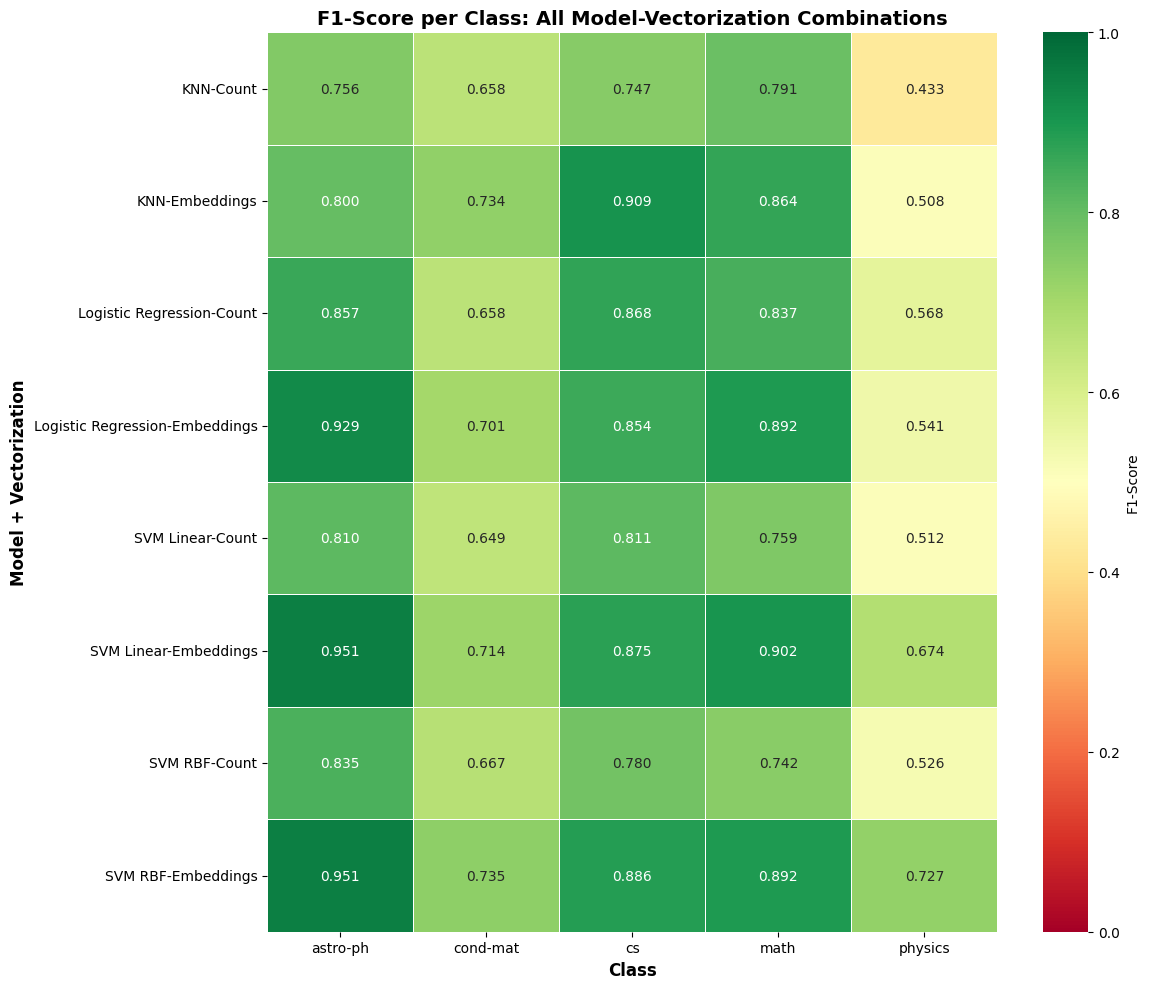


📉 Classes khó phân loại nhất (Average F1-Score):
Class
physics     0.561203
cond-mat    0.689430
math        0.834821
cs          0.841350
astro-ph    0.861160
Name: F1-Score, dtype: float64

📈 Classes dễ phân loại nhất (Average F1-Score):
Class
astro-ph    0.861160
cs          0.841350
math        0.834821
cond-mat    0.689430
physics     0.561203
Name: F1-Score, dtype: float64


In [53]:
# 11. PER-CLASS PERFORMANCE ANALYSIS
# ==============================================================================

print("\n" + "="*80)
print("📈 PHẦN 7: PHÂN TÍCH PERFORMANCE THEO CLASS")
print("="*80)

# Tạo DataFrame cho per-class comparison
per_class_data = []

for result in all_results:
    report = result['report']
    for label in sorted_labels:
        if label in report:
            per_class_data.append({
                'Model': result['model_name'],
                'Vectorization': result['vectorization'],
                'Class': label,
                'Precision': report[label]['precision'],
                'Recall': report[label]['recall'],
                'F1-Score': report[label]['f1-score'],
                'Support': report[label]['support']
            })

per_class_df = pd.DataFrame(per_class_data)

# Heatmap: F1-Score per class cho mỗi combination
pivot_class = per_class_df.pivot_table(
    index=['Model', 'Vectorization'], 
    columns='Class', 
    values='F1-Score'
)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_class, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, linewidths=0.5, 
            cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score per Class: All Model-Vectorization Combinations', 
          fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Model + Vectorization', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Classes khó phân loại nhất
print("\n📉 Classes khó phân loại nhất (Average F1-Score):")
avg_f1_per_class = per_class_df.groupby('Class')['F1-Score'].mean().sort_values()
print(avg_f1_per_class)

# Classes dễ phân loại nhất
print("\n📈 Classes dễ phân loại nhất (Average F1-Score):")
print(avg_f1_per_class.sort_values(ascending=False))

In [59]:
# 12. HYPERPARAMETER TUNING VỚI GRID SEARCH
def tune_hyperparameters_grid(model, param_grid, X_train, y_train, 
                              model_name="Model", vectorization=""):
    """
    Tìm hyperparameters tốt nhất bằng GridSearchCV với 5-fold CV
    """
    full_name = f"{model_name} ({vectorization})"
    print(f"\n🔍 Tuning {full_name}...")
    print(f"   Param grid: {param_grid}")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"✅ Best parameters: {grid_search.best_params_}")
    print(f"✅ Best CV F1-score: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_, grid_search


# ✅ Chọn model Embeddings tốt nhất theo F1
best_emb = max(results_embeddings, key=lambda x: x['test_f1'])
print(f"\n🏆 Best Embeddings: {best_emb['model_name']} (F1-score: {best_emb['test_f1']:.4f})")

# ✅ Nếu là SVM RBF → chạy GridSearchCV
if best_emb['model_name'] == 'SVM RBF':
    param_grid_emb = {
        'C': [0.1, 1.0, 10.0],
        'gamma': ['scale', 0.01, 0.1],
        'class_weight': [None, 'balanced']
    }
    tuned_model_emb, _ = tune_hyperparameters_grid(
        SVC(kernel='rbf', random_state=42),
        param_grid_emb,
        X_train_embeddings, y_train,
        model_name="SVM RBF",
        vectorization="Embeddings"
    )
    
    # ✅ Evaluate tuned model
    result_tuned_emb = evaluate_model(
        tuned_model_emb,
        X_train_embeddings, y_train,
        X_test_embeddings, y_test,
        model_name="SVM RBF (Tuned)",
        vectorization_method="Embeddings"
    )

    # ✅ Lưu kết quả vào danh sách
    results_embeddings.append(result_tuned_emb)



🏆 Best Embeddings: SVM RBF (F1-score: 0.8383)

🔍 Tuning SVM RBF (Embeddings)...
   Param grid: {'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 0.01, 0.1], 'class_weight': [None, 'balanced']}
Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ Best parameters: {'C': 10.0, 'class_weight': None, 'gamma': 0.1}
✅ Best CV F1-score: 0.8414
🔄 Đang huấn luyện SVM RBF (Tuned) (Embeddings)...
✅ SVM RBF (Tuned) (Embeddings) - Completed!
   Train → Acc: 0.9250 | F1: 0.9248
   Test  → Acc: 0.8450 | F1: 0.8432
   Gap   → Acc: +0.0800 | F1: +0.0816 ⚠️ Potential overfitting!




📊 ĐÁNH GIÁ MÔ HÌNH SAU KHI TUNING (SVM RBF - Embeddings)
   Metric   Before    After
 Accuracy 0.840000 0.845000
Precision 0.849199 0.853810
   Recall 0.840000 0.845000
 F1-Score 0.838286 0.843245


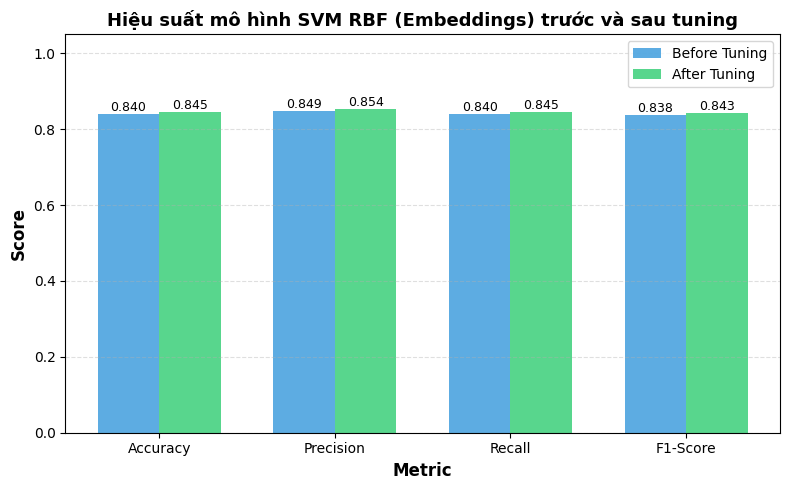

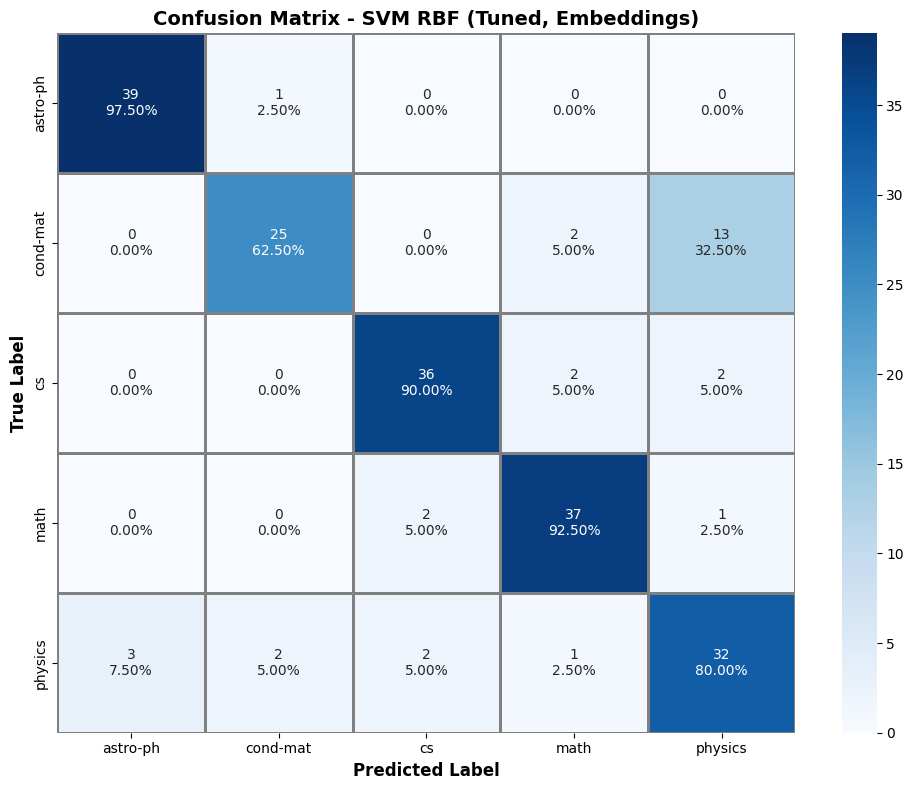


📋 Classification Report (After Tuning):
              precision    recall  f1-score   support

    astro-ph       0.93      0.97      0.95        40
    cond-mat       0.89      0.62      0.74        40
          cs       0.90      0.90      0.90        40
        math       0.88      0.93      0.90        40
     physics       0.67      0.80      0.73        40

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200


🏁 BẢNG XẾP HẠNG CUỐI CÙNG SAU KHI TUNING
              Model Vectorization  Accuracy  Precision  Recall  F1-Score
    SVM RBF (Tuned)    Embeddings     0.845   0.853810   0.845  0.843245
            SVM RBF    Embeddings     0.840   0.849199   0.840  0.838286
         SVM Linear    Embeddings     0.825   0.829658   0.825  0.823473
Logistic Regression    Embeddings     0.790   0.779625   0.790  0.783127
                KNN    Embeddings     0.775   0.781103   0.775 

In [60]:
# %% [markdown]
# ## 13. ĐÁNH GIÁ CHI TIẾT SAU KHI TUNING

# %%
print("\n" + "="*90)
print("📊 ĐÁNH GIÁ MÔ HÌNH SAU KHI TUNING (SVM RBF - Embeddings)")
print("="*90)

# So sánh trực tiếp trước và sau khi tuning
before_tuning = next(
    (r for r in results_embeddings if r['model_name'] == 'SVM RBF'),
    None
)

after_tuning = result_tuned_emb

comparison_tuning = pd.DataFrame([
    {
        'Metric': 'Accuracy',
        'Before': before_tuning['test_accuracy'],
        'After': after_tuning['test_accuracy']
    },
    {
        'Metric': 'Precision',
        'Before': before_tuning['test_precision'],
        'After': after_tuning['test_precision']
    },
    {
        'Metric': 'Recall',
        'Before': before_tuning['test_recall'],
        'After': after_tuning['test_recall']
    },
    {
        'Metric': 'F1-Score',
        'Before': before_tuning['test_f1'],
        'After': after_tuning['test_f1']
    }
])

print(comparison_tuning.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison_tuning))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_tuning['Before'], width, label='Before Tuning', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_tuning['After'], width, label='After Tuning', color='#2ecc71', alpha=0.8)

# Hiển thị giá trị trên cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Hiệu suất mô hình SVM RBF (Embeddings) trước và sau tuning', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_tuning['Metric'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# %%
# Vẽ confusion matrix sau tuning
plot_confusion_matrix(
    y_test,
    after_tuning['y_pred'],
    sorted_labels,
    title="Confusion Matrix - SVM RBF (Tuned, Embeddings)"
)

# %%
# In classification report chi tiết
print("\n📋 Classification Report (After Tuning):")
print(classification_report(
    y_test,
    after_tuning['y_pred'],
    target_names=sorted_labels,
    zero_division=0
))

# %%
# Thêm kết quả tuned vào bảng tổng hợp và hiển thị lại top models
all_results_final = results_count + results_embeddings

final_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Vectorization': r['vectorization'],
        'Accuracy': r['test_accuracy'],
        'Precision': r['test_precision'],
        'Recall': r['test_recall'],
        'F1-Score': r['test_f1']
    }
    for r in all_results_final
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("🏁 BẢNG XẾP HẠNG CUỐI CÙNG SAU KHI TUNING")
print("="*90)
print(final_df.to_string(index=False))
